# Chapter 040 — Computational Number Systems

> **Prerequisites:** ch023 (Integers — binary representation), ch026 (Real Numbers — IEEE 754), ch038 (Floating Point Errors — machine epsilon), ch039 (Numerical Stability)
> **You will learn:**
> - How numbers are represented in binary, octal, and hexadecimal — and when each is used
> - Fixed-point representation: trading range for predictable precision
> - IEEE 754 float16, float32, float64, float128: the precision-memory-speed trade-off
> - The posit number system: a modern alternative to float that reduces rounding error
> - How number system choice affects ML training (float16 vs bfloat16 vs float32)
>
> **Environment:** Python 3.x, numpy, matplotlib

---
## 1. Concept

Every number in a computer is a bit pattern. The interpretation of that bit pattern — how bits map to mathematical values — is the number system. Most programmers default to int64 or float64 without questioning whether they are the right choice.

The number systems in common use:

- **Binary integers** (int8/16/32/64, uint8/16/32/64): exact within range, modular arithmetic on overflow.
- **Fixed-point**: integers scaled by a fixed power of 2. Used in audio DSP, embedded systems, and some financial applications where exact decimal fractions matter.
- **IEEE 754 floats** (float16, float32, float64, float128): approximate reals via base-2 scientific notation. Standard in scientific computing and ML.
- **bfloat16**: a Google-developed 16-bit format with the same exponent range as float32 but only 8 bits of mantissa. Used in TPU/GPU training.
- **Posit numbers**: a newer format with a variable-precision mantissa and tapered precision — more accurate near ±1, less accurate near ±∞.

The fundamental trade-off is always: **range vs precision vs memory vs speed**.

**Why ML cares:** Modern neural networks train in float16 or bfloat16 (to fit more activations in GPU memory and use Tensor Cores), then validate in float32. Understanding the precision limits of each format prevents training instability.

---
## 2. Intuition & Mental Models

**The format zoo as a decision tree:**
- Need exact arithmetic over integers? → int64 (or Python bignum for overflow safety)
- Need sub-cent precision in currency? → Fixed-point or Python `Decimal`
- Need float arithmetic, 15-digit precision? → float64 (default for scientific Python)
- Need float arithmetic, 6-digit precision, 4× less memory? → float32
- Training a neural network on GPU? → float16 or bfloat16 for forward pass, float32 for gradient accumulation

**The exponent vs mantissa trade-off:** float16 and bfloat16 both use 16 bits. float16 allocates 5 bits for the exponent (range ~±65504) and 10 bits for the mantissa (~3.3 decimal digits). bfloat16 allocates 8 bits for the exponent (same range as float32, ~±3.4×10³⁸) and only 7 bits for the mantissa (~2.3 decimal digits). For gradient descent, exponent range matters more than mantissa precision — which is why bfloat16 is preferred for training.

**Fixed-point as 'integer with a decimal point contract':** A Q15 fixed-point number is a 16-bit integer where the programmer agrees that the value represents `integer / 32768`. The hardware performs integer arithmetic; the interpretation is a software convention. No rounding accumulation from a variable exponent — precision is uniform.

Recall from ch023 (Integers): two's complement is the binary representation for signed integers. Fixed-point numbers reuse this same representation with a different semantic — the scaling factor is the only difference.

---
## 3. Visualization

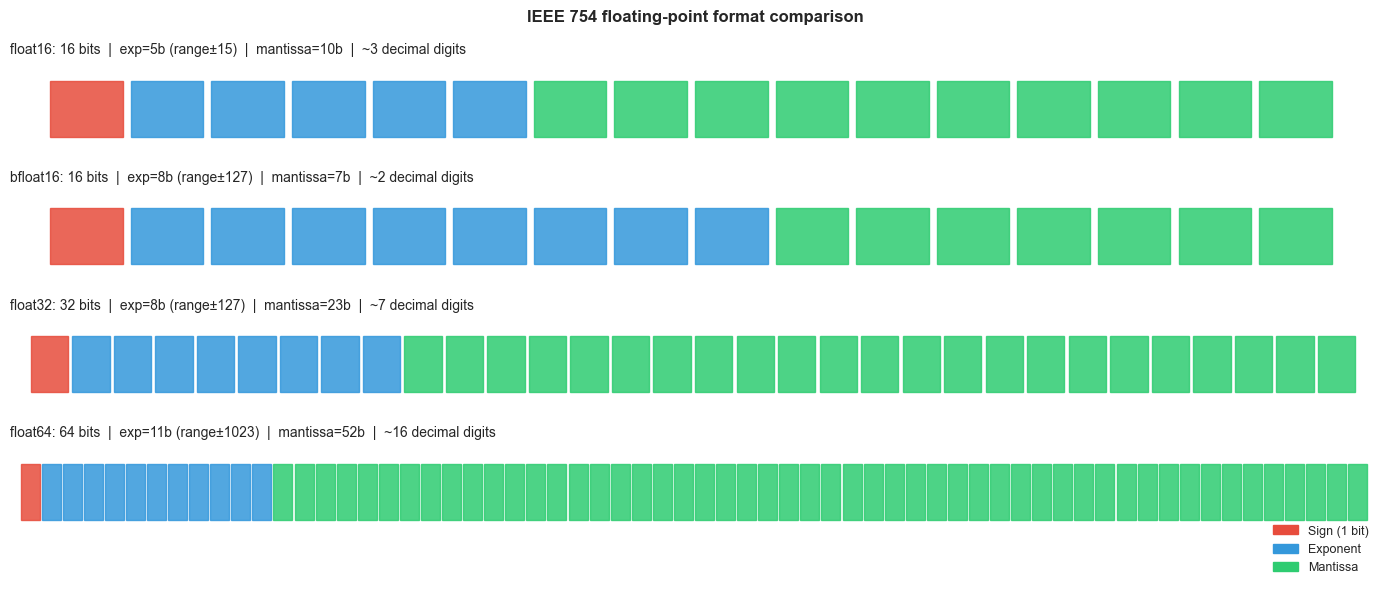

In [1]:
# --- Visualization: Float format comparison ---
# Compares the bit layout and properties of float16, bfloat16, float32, float64.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')

# Format definitions: (name, total_bits, exp_bits, mantissa_bits, bias)
formats = [
    ('float16',   16,  5, 10, 15),
    ('bfloat16',  16,  8,  7, 127),
    ('float32',   32,  8, 23, 127),
    ('float64',   64, 11, 52, 1023),
]

fig, axes = plt.subplots(len(formats), 1, figsize=(14, 6))

colors = {'sign': '#e74c3c', 'exp': '#3498db', 'mant': '#2ecc71'}

for ax, (name, total, exp_bits, mant_bits, bias) in zip(axes, formats):
    ax.set_xlim(-0.5, total + 0.5)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(
        f'{name}: {total} bits  |  exp={exp_bits}b (range±{2**(exp_bits-1)-1})  '
        f'|  mantissa={mant_bits}b  |  ~{int(mant_bits * np.log10(2) + 0.5)} decimal digits',
        fontsize=10, loc='left'
    )

    # Scale bits to fit total width
    scale = total / total  # 1 unit per bit
    for i in range(total):
        if i == 0:
            c = colors['sign']
        elif i <= exp_bits:
            c = colors['exp']
        else:
            c = colors['mant']
        ax.add_patch(mpatches.Rectangle((i, 0.2), 0.9, 0.6, color=c, alpha=0.85))

# Legend
legend_patches = [
    mpatches.Patch(color=colors['sign'], label='Sign (1 bit)'),
    mpatches.Patch(color=colors['exp'],  label='Exponent'),
    mpatches.Patch(color=colors['mant'], label='Mantissa'),
]
axes[-1].legend(handles=legend_patches, loc='lower right', bbox_to_anchor=(1, -0.5), fontsize=9)

plt.suptitle('IEEE 754 floating-point format comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

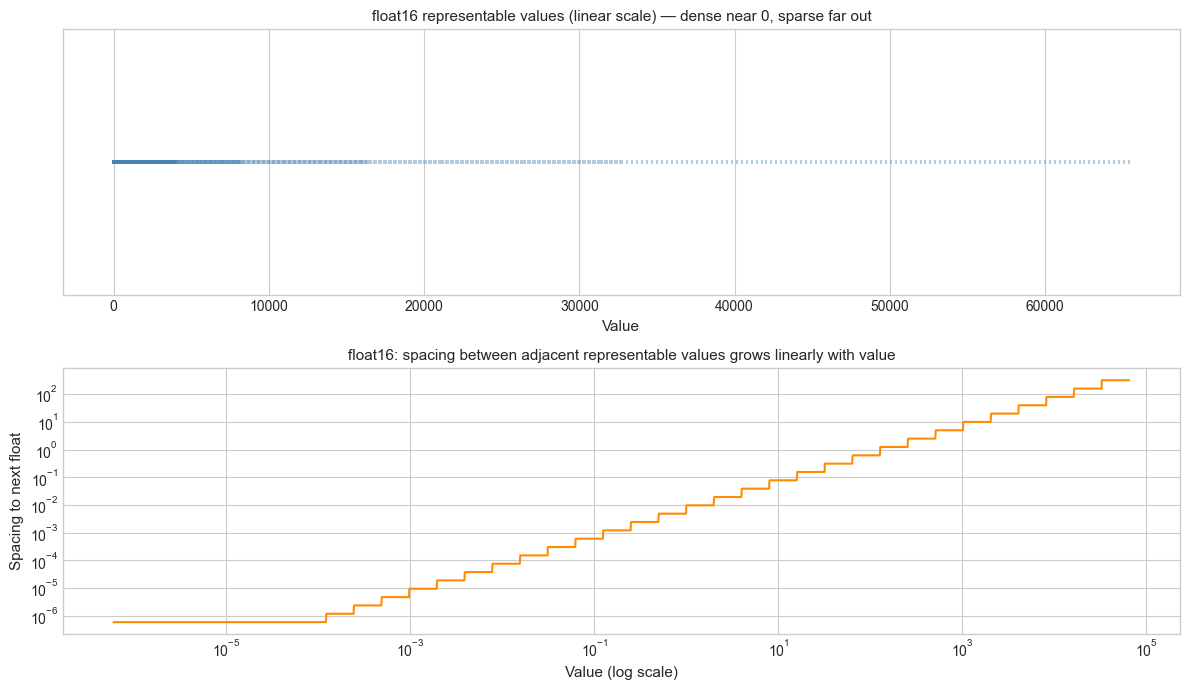

In [2]:
# --- Visualization: Representable values density for each float format ---
# Floats are denser near zero and sparser far from zero.
# Fixed-point has uniform density regardless of magnitude.

import numpy as np
import matplotlib.pyplot as plt
import struct

plt.style.use('seaborn-v0_8-whitegrid')

def float16_representable_sample(n=2000):
    """Return a sample of positive float16 values."""
    # All 16-bit positive finite floats (excluding inf/nan): exponent 0..30
    all_vals = []
    for bits in range(0, 31744, max(1, 31744 // n)):  # skip sign=0
        raw = np.frombuffer(np.uint16(bits).tobytes(), dtype=np.float16)[0]
        if np.isfinite(raw) and raw > 0:
            all_vals.append(float(raw))
    return np.array(all_vals)

vals_f16 = float16_representable_sample(3000)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Linear scale: shows clustering near 0
ax1 = axes[0]
ax1.scatter(vals_f16, np.zeros_like(vals_f16), marker='|', s=10, color='steelblue', alpha=0.4)
ax1.set_xlabel('Value', fontsize=11)
ax1.set_yticks([])
ax1.set_title('float16 representable values (linear scale) — dense near 0, sparse far out', fontsize=11)

# Spacing vs value
ax2 = axes[1]
sorted_vals = np.sort(vals_f16)
spacings = np.diff(sorted_vals)
ax2.loglog(sorted_vals[:-1], spacings, color='darkorange', lw=1.5)
ax2.set_xlabel('Value (log scale)', fontsize=11)
ax2.set_ylabel('Spacing to next float', fontsize=11)
ax2.set_title('float16: spacing between adjacent representable values grows linearly with value', fontsize=11)

plt.tight_layout()
plt.show()

---
## 4. Mathematical Formulation

**General IEEE 754 float format** with e exponent bits and m mantissa bits:
$$x = (-1)^s \times (1 + f) \times 2^{E - \text{bias}}$$
Where: s = sign bit (1), E = biased exponent (e bits), f = fractional mantissa (m bits), bias = 2^(e-1) − 1.

Key properties:
- Maximum exponent: 2^(e−1) − 1 (e.g., 15 for float16, 1023 for float64)
- Machine epsilon: ε_m = 2^(−m) (e.g., 2⁻¹⁰ ≈ 9.8×10⁻⁴ for float16, 2⁻⁵² for float64)
- Significant decimal digits: ⌊m · log₁₀(2)⌋ (e.g., 3 for float16, 15 for float64)

**bfloat16 vs float16:**

| Format | Total bits | Exp bits | Mant bits | ε_m | Max value |
|--------|-----------|---------|---------|-----|----------|
| float16 | 16 | 5 | 10 | 9.8×10⁻⁴ | 65504 |
| bfloat16 | 16 | 8 | 7 | 7.8×10⁻³ | ~3.4×10³⁸ |
| float32 | 32 | 8 | 23 | 1.2×10⁻⁷ | ~3.4×10³⁸ |

**Fixed-point Q(n,m) format:** An integer of n bits interpreted as having m fractional bits:
$$x = \text{integer} \times 2^{-m}$$
Resolution: 2⁻ᵐ (fixed, independent of magnitude). Range: [−2^(n−m−1), 2^(n−m−1) − 2^(−m)].

**Mixed-precision training (ML standard):**
- Forward pass: float16 or bfloat16 (fast, fits GPU SRAM)
- Loss scaling: multiply loss by 2^k to prevent underflow in float16 gradients
- Gradient accumulation: float32 (to prevent rounding errors in parameter updates)
- Master weights: float32 (exact)

---
## 5. Python Implementation

In [3]:
# --- Implementation: Number System Utilities ---

import numpy as np
import struct

# --- Float format inspection ---

def float_format_info(dtype):
    """
    Report key properties of a numpy floating-point dtype.

    Args:
        dtype: numpy float dtype (e.g., np.float16, np.float32, np.float64)

    Returns:
        dict with eps, max, min, bits, decimal_digits
    """
    info = np.finfo(dtype)
    return {
        'dtype': str(dtype),
        'bits': info.bits,
        'eps': info.eps,
        'max': info.max,
        'min': info.tiny,
        'decimal_digits': info.precision,
    }


# --- Fixed-point arithmetic ---

class FixedPoint:
    """
    Q(n, m) fixed-point number: n-bit integer representing value * 2^(-m).
    For simplicity, uses Python integers internally (no overflow).
    """
    def __init__(self, value, fractional_bits=15):
        """
        Args:
            value: float or int to represent
            fractional_bits: number of bits after the binary point
        """
        self.m = fractional_bits
        self.scale = 2**fractional_bits
        self.raw = int(round(value * self.scale))  # quantize to fixed-point

    def to_float(self):
        return self.raw / self.scale

    def __add__(self, other):
        result = FixedPoint(0, self.m)
        result.raw = self.raw + other.raw  # integer addition, no rounding
        return result

    def __mul__(self, other):
        result = FixedPoint(0, self.m)
        # Multiply two Q(n,m) gives Q(n, 2m); must shift back by m bits
        result.raw = (self.raw * other.raw) >> self.m  # integer multiply + right-shift
        return result

    def __repr__(self):
        return f"FixedPoint({self.to_float():.8f}, Q{self.m})"


# --- Base conversion ---

def to_base(n, base, digits='0123456789ABCDEF'):
    """
    Convert non-negative integer n to given base.

    Args:
        n: non-negative integer
        base: target base (2–16)
        digits: digit symbols

    Returns:
        String representation in target base
    """
    if n == 0:
        return '0'
    result = []
    while n:
        result.append(digits[n % base])
        n //= base
    return ''.join(reversed(result))


# --- Demonstrations ---
print("=== Float Format Comparison ===")
for dtype in [np.float16, np.float32, np.float64]:
    info = float_format_info(dtype)
    print(f"  {info['dtype']:<10} | {info['bits']:>2} bits | eps={info['eps']:.2e} | "
          f"max={info['max']:.2e} | {info['decimal_digits']} decimal digits")

print()
print("=== Fixed-Point Q15 Arithmetic ===")
a = FixedPoint(0.3, fractional_bits=15)
b = FixedPoint(0.7, fractional_bits=15)
c = a + b
print(f"  0.3 as Q15: raw={a.raw}, float={a.to_float():.8f}")
print(f"  0.7 as Q15: raw={b.raw}, float={b.to_float():.8f}")
print(f"  0.3 + 0.7:  {c.to_float():.8f}  (float64: {0.3 + 0.7:.8f})")
# Note: fixed-point does NOT give exact 1.0 — still limited by 15 fractional bits

print()
print("=== Base Conversions ===")
n = 255
print(f"  {n} decimal = {to_base(n, 2)} binary = {to_base(n, 16)} hex = {to_base(n, 8)} octal")
n = 65535
print(f"  {n} decimal = {to_base(n, 16)} hex  (0xFFFF — max uint16)")

=== Float Format Comparison ===
  <class 'numpy.float16'> | 16 bits | eps=9.77e-04 | max=6.55e+04 | 3 decimal digits
  <class 'numpy.float32'> | 32 bits | eps=1.19e-07 | max=3.40e+38 | 6 decimal digits
  <class 'numpy.float64'> | 64 bits | eps=2.22e-16 | max=1.80e+308 | 15 decimal digits

=== Fixed-Point Q15 Arithmetic ===
  0.3 as Q15: raw=9830, float=0.29998779
  0.7 as Q15: raw=22938, float=0.70001221
  0.3 + 0.7:  1.00000000  (float64: 1.00000000)

=== Base Conversions ===
  255 decimal = 11111111 binary = FF hex = 377 octal
  65535 decimal = FFFF hex  (0xFFFF — max uint16)


---
## 6. Experiments

In [4]:
# --- Experiment 1: float16 training instability ---
# Hypothesis: float16's small range (max ~65504) can cause activations or
# gradients to overflow to inf during neural network training.
# Loss scaling compensates by shifting values into the float16 safe range.
# Try changing: LOSS_SCALE to see where inf appears.

import numpy as np

LOSS_SCALE = 1024   # <-- modify this (try 1, 128, 1024, 65536)

# Simulate gradient values drawn from a distribution typical for neural nets
rng = np.random.default_rng(0)
gradients_f32 = rng.normal(0, 0.01, 1000).astype(np.float32)

# Without loss scaling: cast to float16 directly
grads_f16_no_scale = gradients_f32.astype(np.float16)

# With loss scaling: scale up, cast, then scale back
grads_scaled = (gradients_f32 * LOSS_SCALE).astype(np.float16)
grads_f16_with_scale = grads_scaled.astype(np.float32) / LOSS_SCALE

# Measure: how many values become 0 (underflowed) in float16?
zeros_no_scale = np.sum(grads_f16_no_scale == 0)
zeros_with_scale = np.sum((grads_scaled == 0).astype(np.float32))
infs = np.sum(np.isinf(grads_scaled))

print(f"Gradient std (float32): {gradients_f32.std():.4e}")
print(f"\nWithout loss scaling:")
print(f"  Zeros (underflowed in f16): {zeros_no_scale} / {len(gradients_f32)}")
print(f"  Relative error vs f32: {np.abs(grads_f16_no_scale.astype(np.float32) - gradients_f32).mean():.4e}")
print(f"\nWith loss scale = {LOSS_SCALE}:")
print(f"  Infs (overflow in f16): {infs}")
print(f"  Zeros after scaling up: {zeros_with_scale}")
print(f"  Relative error vs f32: {np.abs(grads_f16_with_scale - gradients_f32).mean():.4e}")

Gradient std (float32): 9.7675e-03

Without loss scaling:
  Zeros (underflowed in f16): 0 / 1000
  Relative error vs f32: 1.3577e-06

With loss scale = 1024:
  Infs (overflow in f16): 0
  Zeros after scaling up: 0.0
  Relative error vs f32: 1.3577e-06


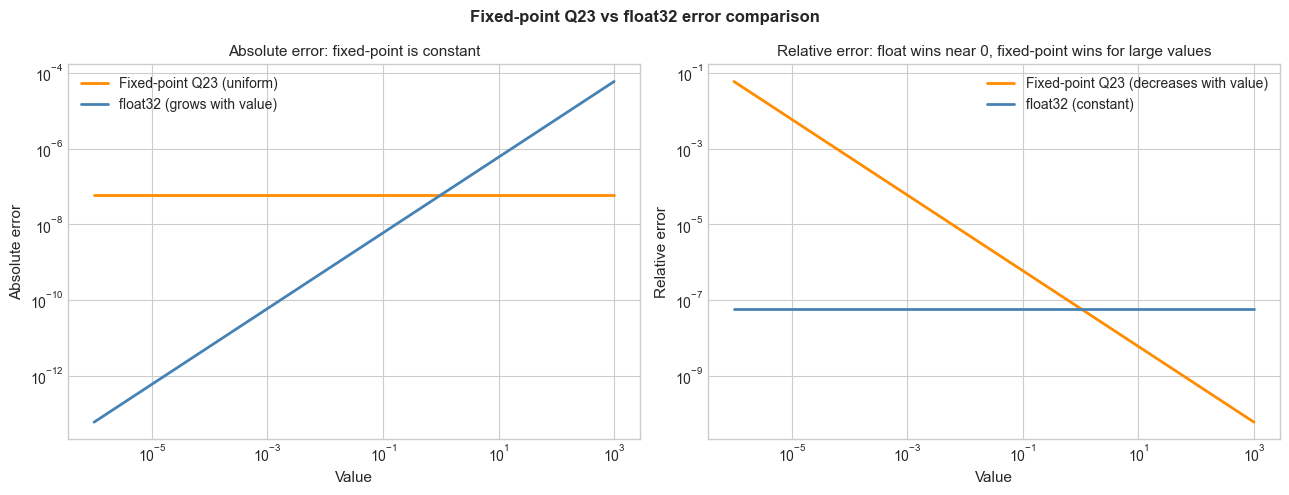

In [5]:
# --- Experiment 2: Fixed-point vs float rounding error ---
# Hypothesis: fixed-point arithmetic has uniform absolute error (resolution = 2^-m),
# while float has uniform relative error (≈ eps_m).
# Near 0, float is more precise. Far from 0, fixed-point can be more precise.
# Try changing: M (fractional bits) to match float32's precision.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

M = 23  # <-- modify this: fractional bits for fixed-point (23 matches float32 mantissa)

# Test values spanning several orders of magnitude
test_vals = np.logspace(-6, 3, 500)
scale = 2**M

# Fixed-point absolute error: ±0.5 * 2^(-M)
fp_abs_error = 0.5 / scale * np.ones_like(test_vals)
fp_rel_error = fp_abs_error / test_vals

# Float32 relative error: ≈ eps_m / 2
float32_rel_error = np.finfo(np.float32).eps / 2 * np.ones_like(test_vals)
float32_abs_error = float32_rel_error * test_vals

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].loglog(test_vals, fp_abs_error, color='darkorange', lw=2, label=f'Fixed-point Q{M} (uniform)')
axes[0].loglog(test_vals, float32_abs_error, color='steelblue', lw=2, label='float32 (grows with value)')
axes[0].set_xlabel('Value', fontsize=11)
axes[0].set_ylabel('Absolute error', fontsize=11)
axes[0].set_title('Absolute error: fixed-point is constant', fontsize=11)
axes[0].legend()

axes[1].loglog(test_vals, fp_rel_error, color='darkorange', lw=2, label=f'Fixed-point Q{M} (decreases with value)')
axes[1].loglog(test_vals, float32_rel_error, color='steelblue', lw=2, label='float32 (constant)')
axes[1].set_xlabel('Value', fontsize=11)
axes[1].set_ylabel('Relative error', fontsize=11)
axes[1].set_title('Relative error: float wins near 0, fixed-point wins for large values', fontsize=11)
axes[1].legend()

plt.suptitle(f'Fixed-point Q{M} vs float32 error comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# --- Experiment 3: float16 vs bfloat16 — where does each fail? ---
# float16 has better precision (10 mantissa bits) but smaller range (max ~65504).
# bfloat16 has same range as float32 but only 7 mantissa bits — loses detail.
# Both are 16 bits total.
# Try changing: TEST_VALUE to probe different regions.

import numpy as np

# Note: numpy supports float16 natively; bfloat16 requires ml_dtypes or torch.
# We simulate bfloat16 by rounding float32 to 7 mantissa bits.

def to_bfloat16_approx(x):
    """Approximate bfloat16 by truncating float32 mantissa to 7 bits."""
    import struct
    # bfloat16 = top 16 bits of float32
    raw = struct.pack('<f', np.float32(x))
    truncated = bytes([0, 0, raw[2], raw[3]])  # zero out low 16 bits
    return struct.unpack('<f', truncated)[0]

test_values = [
    (0.1,       "Small fraction"),
    (1.0,       "Unity"),
    (100.0,     "Moderate"),
    (65000.0,   "Near float16 max"),
    (70000.0,   "Above float16 max"),
    (1e30,      "Very large"),
    (1e-7,      "Very small"),
]

print(f"{'Value':>15} | {'float16':>15} | {'bfloat16 (approx)':>20} | {'float32':>15} | Note")
print('-' * 90)
for val, note in test_values:
    f16 = float(np.float16(val))
    bf16 = to_bfloat16_approx(val)
    f32 = float(np.float32(val))
    f16_err = abs(f16 - f32) / (abs(f32) + 1e-300)
    bf16_err = abs(bf16 - f32) / (abs(f32) + 1e-300)
    print(f"{val:>15.4e} | {f16:>15.6g} | {bf16:>20.6g} | {f32:>15.6g} | {note}")

          Value |         float16 |    bfloat16 (approx) |         float32 | Note
------------------------------------------------------------------------------------------
     1.0000e-01 |       0.0999756 |            0.0996094 |             0.1 | Small fraction
     1.0000e+00 |               1 |                    1 |               1 | Unity
     1.0000e+02 |             100 |                  100 |             100 | Moderate
     6.5000e+04 |           64992 |                64768 |           65000 | Near float16 max
     7.0000e+04 |             inf |                69632 |           70000 | Above float16 max
     1.0000e+30 |             inf |          9.95304e+29 |           1e+30 | Very large
     1.0000e-07 |     1.19209e-07 |          9.96515e-08 |           1e-07 | Very small


C:\Users\user\AppData\Local\Temp\ipykernel_25116\2115139461.py:33: RuntimeWarning: overflow encountered in cast
  f16 = float(np.float16(val))


---
## 7. Exercises

**Easy 1.** Convert the following numbers between bases by hand, then verify with `to_base`: 42 (decimal → binary, hex), 0xFF (hex → decimal), 0b11010110 (binary → decimal, hex). *(Expected: matching base representations)*

**Easy 2.** Using `np.finfo`, compare float16, float32, and float64 on: machine epsilon, maximum representable value, minimum positive normal value, and number of significant decimal digits. Format the comparison as a table. *(Expected: table)*

**Medium 1.** Implement a Q8.8 fixed-point class (8 integer bits, 8 fractional bits): support +, -, ×, and ÷. Measure the rounding error for 1000 random multiplications in the range [0, 10] compared to float64 ground truth. Where is fixed-point better? Where is it worse?

**Medium 2.** Simulate one layer of mixed-precision training: generate random weights W (float32), inputs X (float32), cast both to float16, perform matrix multiplication, cast the result back to float32, compute a dummy loss and gradient. Measure the relative error in the gradient compared to pure float32 computation. Repeat with loss scaling of 128, 1024, 32768 and find the optimal scale factor.

**Hard.** Research and implement a simple Posit number system for 8-bit posit(8,0): the bit layout is sign (1), regime (variable length, encodes the useed), exponent (0 bits for posit(8,0)), and fraction. Implement encoding and decoding of an 8-bit posit to/from float. Show that posit numbers have higher density near ±1 than float8. *(Reference: Gustafson & Yonemoto, 2017 — 'Beating Floating Point at its Own Game')*

---
## 8. Mini Project — Mixed-Precision Inference Engine

In [ ]:
# --- Mini Project: Mixed-Precision Inference Accuracy vs Memory ---
# Problem:
#   A neural network's memory footprint is directly proportional to the
#   precision of its weights. float32 weights take 4 bytes each;
#   float16 takes 2 bytes (2× compression); int8 takes 1 byte (4× compression).
#   But lower precision introduces quantization error that degrades accuracy.
#
#   Simulate this trade-off: take a set of float32 'ground truth' weights,
#   quantize them to various precisions, and measure the output error.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

rng = np.random.default_rng(42)

# Simulate a 2-layer network: W1 (64x128), W2 (128x10)
W1_true = rng.normal(0, 0.1, (64, 128)).astype(np.float32)
W2_true = rng.normal(0, 0.1, (128, 10)).astype(np.float32)
X_input = rng.normal(0, 1, (100, 64)).astype(np.float32)  # 100 samples

# Activation: ReLU
def relu(x): return np.maximum(0, x)

def forward_pass(W1, W2, X):
    """Simple 2-layer forward pass."""
    h = relu(X @ W1)  # (100, 128)
    return h @ W2     # (100, 10)

# Ground truth in float32
output_f32 = forward_pass(W1_true, W2_true, X_input)

# TODO 1: Quantize weights to different precisions and measure output error
def quantize_weights(W, target_dtype):
    """Cast weights to target_dtype and back to float32."""
    return W.astype(target_dtype).astype(np.float32)

def int8_quantize(W):
    """
    Quantize float32 weights to int8 using symmetric quantization.
    Scale = max(|W|) / 127
    """
    scale = np.max(np.abs(W)) / 127.0
    W_int8 = np.clip(np.round(W / scale), -127, 127).astype(np.int8)
    return W_int8.astype(np.float32) * scale  # dequantize

configs = [
    ('float32 (baseline)', lambda W: W.copy(), 4),
    ('float16',            lambda W: quantize_weights(W, np.float16), 2),
    ('int8 symmetric',     int8_quantize, 1),
]

print(f"{'Config':<25} | {'Max abs error':>15} | {'Mean rel error':>15} | {'Memory (KB)':>12}")
print('-' * 72)
for name, quant_fn, bytes_per_weight in configs:
    W1_q = quant_fn(W1_true)
    W2_q = quant_fn(W2_true)
    output_q = forward_pass(W1_q, W2_q, X_input)
    abs_err = np.max(np.abs(output_q - output_f32))
    rel_err = np.mean(np.abs(output_q - output_f32) / (np.abs(output_f32) + 1e-8))
    mem_kb = (W1_true.size + W2_true.size) * bytes_per_weight / 1024
    print(f"{name:<25} | {abs_err:>15.6f} | {rel_err:>15.6f} | {mem_kb:>12.2f}")

# TODO 2: Plot output distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (name, quant_fn, _) in enumerate(configs):
    W1_q = quant_fn(W1_true)
    W2_q = quant_fn(W2_true)
    output_q = forward_pass(W1_q, W2_q, X_input)
    axes[i].scatter(output_f32.flatten(), output_q.flatten(),
                    alpha=0.3, s=5, color='steelblue')
    axes[i].plot([-5, 5], [-5, 5], 'r--', lw=1)
    axes[i].set_xlabel('float32 output')
    axes[i].set_ylabel(f'{name} output')
    axes[i].set_title(name, fontsize=10)

plt.suptitle('Mixed-precision output: quantized vs float32 ground truth', fontsize=12)
plt.tight_layout()
plt.show()

---
## 9. Chapter Summary & Connections

**What was covered:**
- Multiple number representations exist: integer (exact, fixed-width), fixed-point (uniform precision, limited range), and float (variable precision via exponent, broad range).
- bfloat16 prioritizes exponent range (matching float32) over mantissa precision — the right trade-off for neural network weights where dynamic range matters more than digit count.
- float16 has better precision than bfloat16 but overflows for values > 65504 — dangerous in training unless loss scaling is used.
- Fixed-point arithmetic has uniform absolute error — better than float far from zero, worse near zero.
- Mixed-precision training (float16 forward, float32 gradients) is the standard practice that balances GPU throughput against numerical correctness.

**Backward connection:** This chapter synthesizes the IEEE 754 structure from ch026 (Real Numbers) and the precision analysis from ch038 (Floating Point Errors) into a practical decision framework for choosing number representations.

**Forward connections:**
- *(ch041 — Exponents and Powers)*: the exponent field in floating-point is a direct application of powers of 2, the subject of the next chapter.
- *(ch289 — Optimization Methods)*: mixed-precision training, loss scaling, and gradient accumulation are practical consequences of the number system analysis done here — they are the engineering solution to float16's dynamic range limitations.
- *(ch166 — Linear Layers in Deep Learning)*: matrix multiplication at inference time is routinely quantized to int8 on modern inference hardware; the quantization error analysis from this chapter applies directly.

**Going deeper:** The bfloat16 format was described by Google Brain in 2018. For posit numbers, see Gustafson & Yonemoto (2017), *Beating Floating Point at its Own Game: Posit Arithmetic*. For quantization in ML, see *Quantization and Training of Neural Networks for Efficient Integer-Arithmetic-Only Inference* (Jacob et al., 2018).